In [148]:
import pandas as pd
import seaborn as sns
data=pd.read_csv('bank.csv')
print(data)

       age          job  marital  education default  balance housing loan  \
0       59       admin.  married  secondary      no     2343     yes   no   
1       56       admin.  married  secondary      no       45      no   no   
2       41   technician  married  secondary      no     1270     yes   no   
3       55     services  married  secondary      no     2476     yes   no   
4       54       admin.  married   tertiary      no      184      no   no   
...    ...          ...      ...        ...     ...      ...     ...  ...   
11157   33  blue-collar   single    primary      no        1     yes   no   
11158   39     services  married  secondary      no      733      no   no   
11159   32   technician   single  secondary      no       29      no   no   
11160   43   technician  married  secondary      no        0      no  yes   
11161   34   technician  married  secondary      no        0      no   no   

        contact  day month  duration  campaign  pdays  previous poutcome  \

In [149]:
data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [150]:
data.duplicated().sum()

np.int64(0)

<Axes: ylabel='age'>

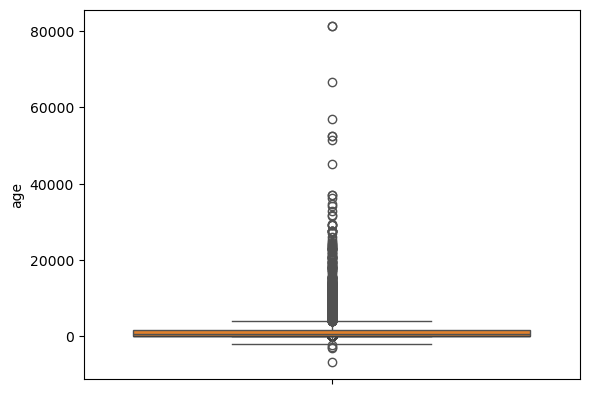

In [151]:
sns.boxplot(data['age'])
sns.boxplot(data['balance'])

In [152]:
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)
IQR = Q3 - Q1

data = data[(data['age'] >= Q1 - 1.5*IQR) & (data['age'] <= Q3 + 1.5*IQR)]

<Axes: ylabel='age'>

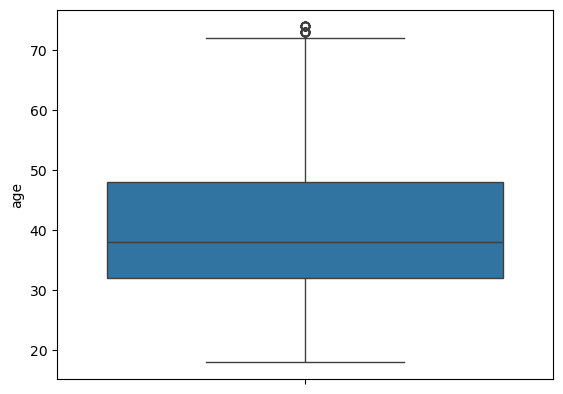

In [153]:
sns.boxplot(data['age'])

In [154]:
data = pd.get_dummies(data, drop_first=True)

In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In [156]:
X = data.drop('deposit_yes', axis=1)
y = data['deposit_yes']

In [157]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [158]:
print(X.shape)
print(type(X))

(10991, 42)
<class 'numpy.ndarray'>


Visualization

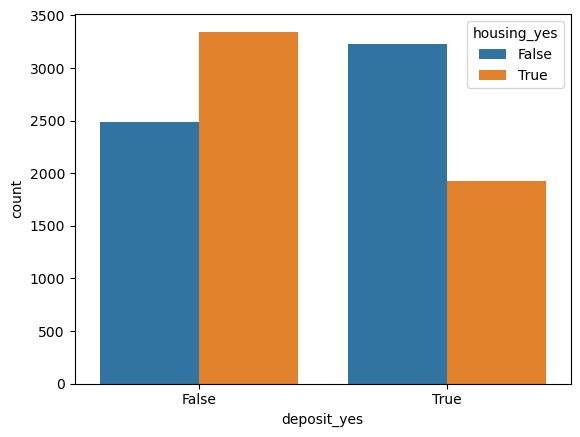

In [159]:
import matplotlib.pyplot as plt
sns.countplot(x=y, hue=data['housing_yes'])
plt.show()

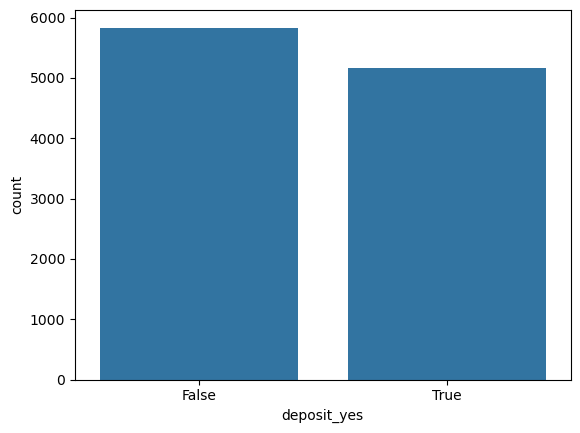

In [160]:
sns.countplot(x='deposit_yes', data=data)
plt.show()

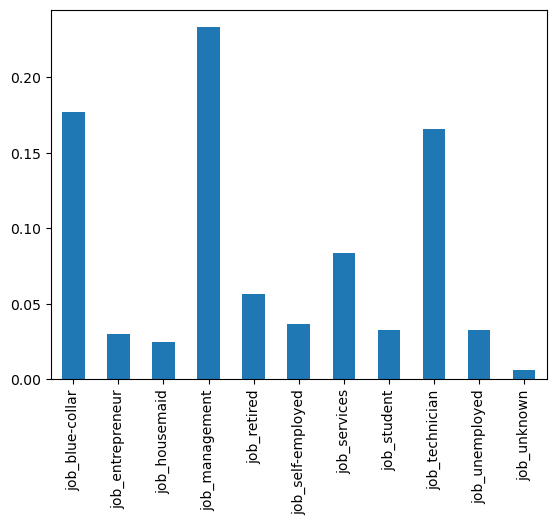

In [161]:
job_cols = [col for col in data.columns if 'job_' in col]

data[job_cols].mean().plot(kind='bar')
plt.xticks(rotation=90)
plt.show()

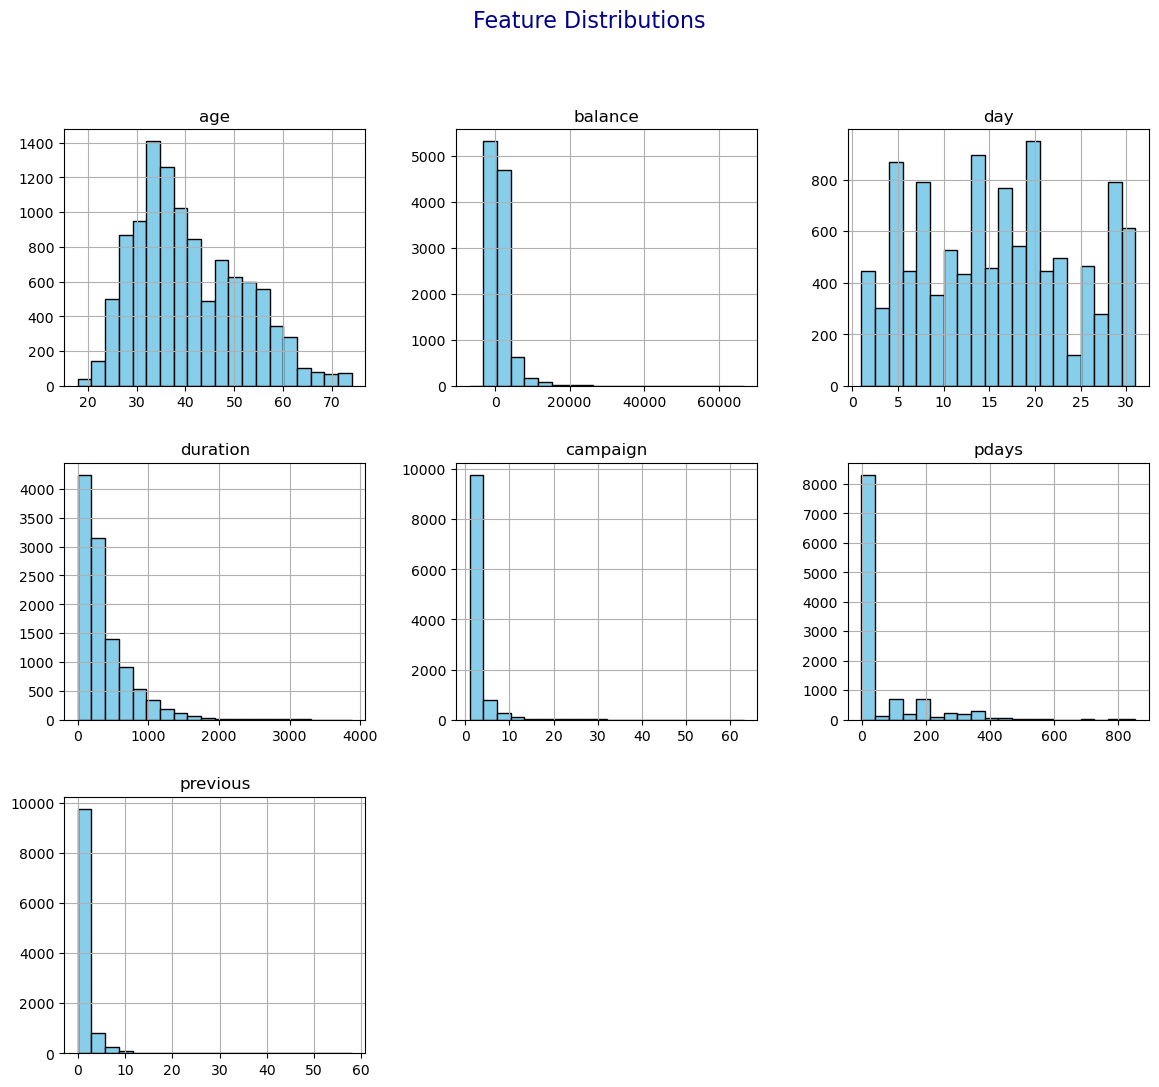

In [162]:
pd.DataFrame(data).hist(figsize=(14,12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16, color='darkblue')
plt.show()

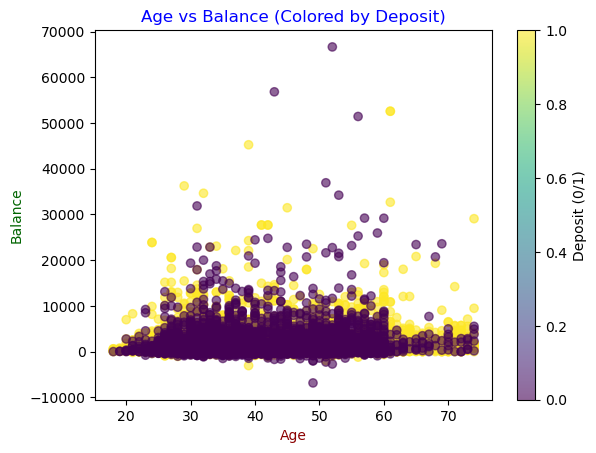

In [163]:
plt.scatter(data['age'], data['balance'], 
            c=data['deposit_yes'], cmap='viridis', alpha=0.6)

plt.xlabel("Age", color='darkred')
plt.ylabel("Balance", color='darkgreen')
plt.title("Age vs Balance (Colored by Deposit)", color='blue')
plt.colorbar(label="Deposit (0/1)")
plt.show()

/tmp/ipykernel_21108/1074448983.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=data['deposit_yes'], y=data['age'], palette="Set3")


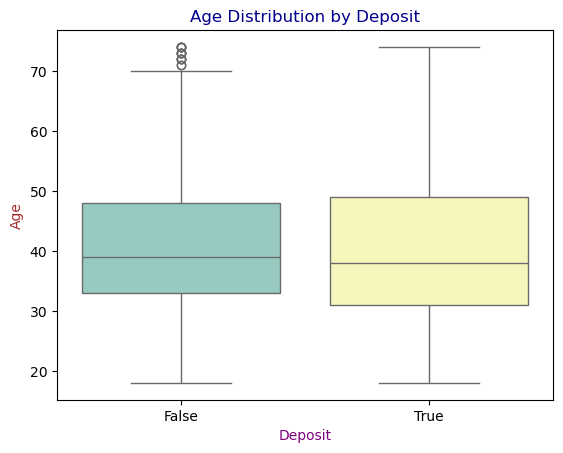

In [164]:
sns.boxplot(x=data['deposit_yes'], y=data['age'], palette="Set3")

plt.xlabel("Deposit", color='purple')
plt.ylabel("Age", color='brown')
plt.title("Age Distribution by Deposit", color='darkblue')
plt.show()

/tmp/ipykernel_21108/2464359210.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=data['deposit_yes'], y=data['balance'], palette="Spectral")


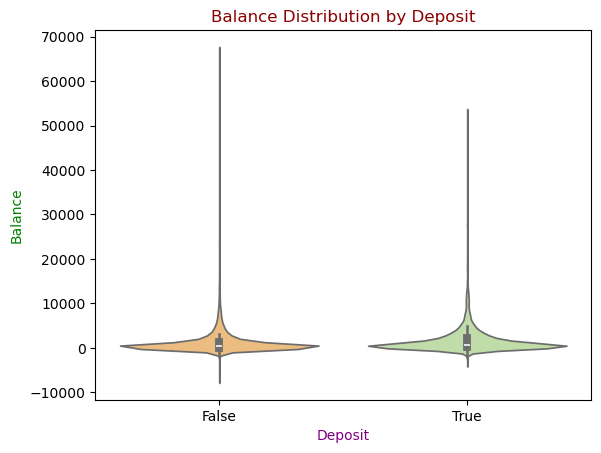

In [165]:
sns.violinplot(x=data['deposit_yes'], y=data['balance'], palette="Spectral")

plt.xlabel("Deposit", color='purple')
plt.ylabel("Balance", color='green')
plt.title("Balance Distribution by Deposit", color='darkred')
plt.show()

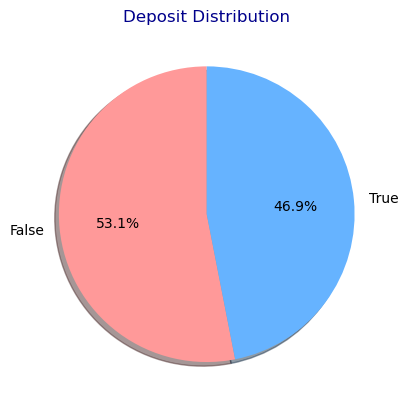

In [166]:
colors = ['#ff9999','#66b3ff']

data['deposit_yes'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True
)

plt.title("Deposit Distribution", color='darkblue')
plt.ylabel("")
plt.show()

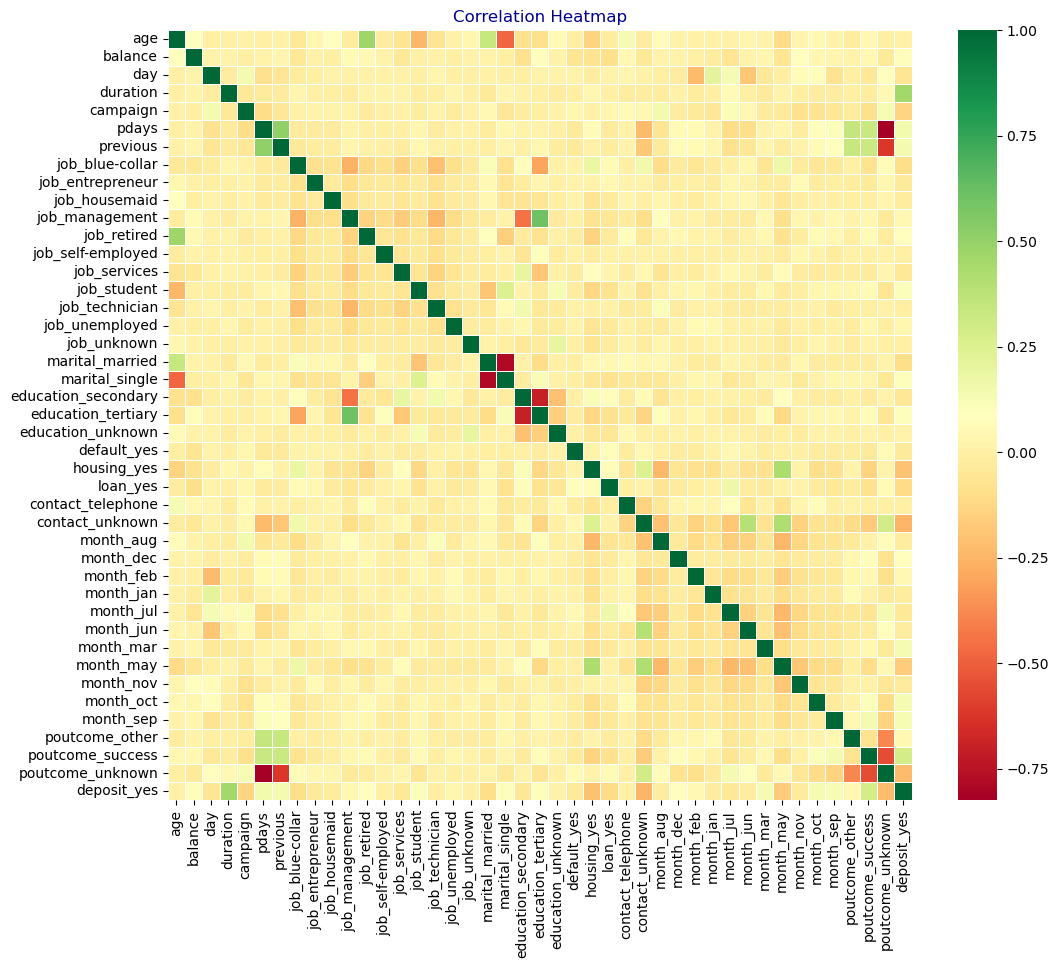

In [167]:
plt.figure(figsize=(12,10))

sns.heatmap(data.corr(), cmap="RdYlGn", linewidths=0.5)

plt.title("Correlation Heatmap", color='darkblue')
plt.show()

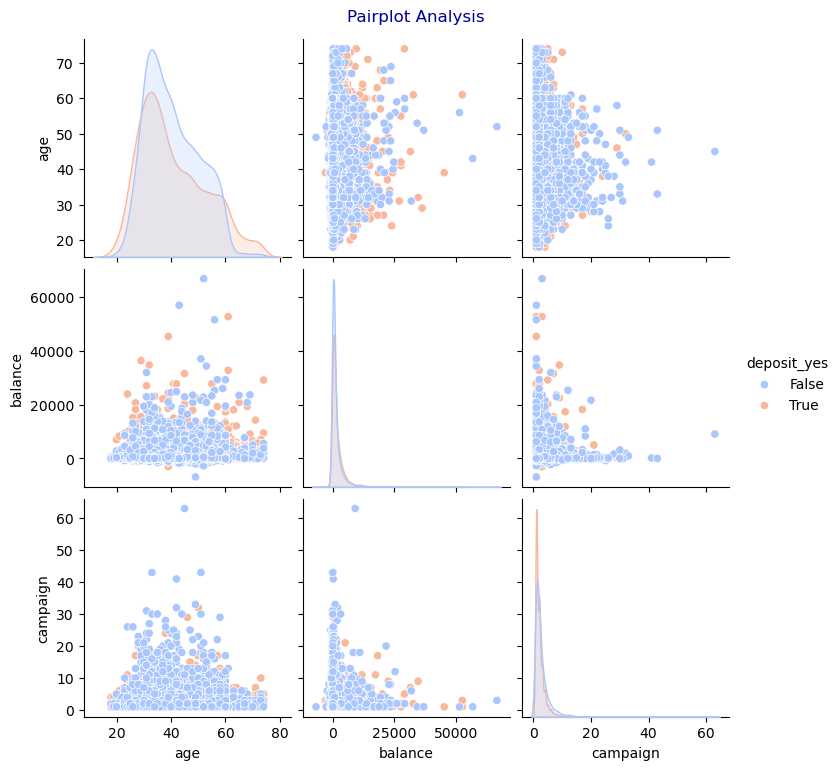

In [168]:
sns.pairplot(
    data[['age','balance','campaign','deposit_yes']],
    hue='deposit_yes',
    palette='coolwarm'
)

plt.suptitle("Pairplot Analysis", y=1.02, color='darkblue')
plt.show()

model bulding

In [169]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [170]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Accuracy:", acc_lr)

Logistic Accuracy: 0.8335607094133697


In [171]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

Decision Tree Accuracy: 0.8135516143701682


In [172]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

Random Forest Accuracy: 0.8562983174170077


In [173]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred_gb)

print("Gradient Boosting Accuracy:", acc_gb)

Gradient Boosting Accuracy: 0.8713051386994088


In [174]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", acc_xgb)

XGBoost Accuracy: 0.8622100954979536


In [175]:
%pip install lightgbm
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    random_state=42
)

lgb.fit(X_train, y_train)

y_pred_lgb = lgb.predict(X_test)
acc_lgb = accuracy_score(y_test, y_pred_lgb)

print("LightGBM Accuracy:", acc_lgb)

Note: you may need to restart the kernel to use updated packages.
[LightGBM] [Info] Number of positive: 4125, number of negative: 4667
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001808 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1013
[LightGBM] [Info] Number of data points in the train set: 8792, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.469177 -> initscore=-0.123450
[LightGBM] [Info] Start training from score -0.123450
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/home/user/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [176]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

model = XGBClassifier(random_state=42)

params = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

random = RandomizedSearchCV(model, params, n_iter=10, cv=3, n_jobs=-1)
random.fit(X_train, y_train)

best_model = random.best_estimator_

In [177]:
import pandas as pd

importances = best_model.feature_importances_

In [178]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X, y, cv=5)
print(scores.mean())

0.8174913652950861


In [179]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.867212369258754
              precision    recall  f1-score   support

       False       0.90      0.84      0.87      1167
        True       0.84      0.89      0.86      1032

    accuracy                           0.87      2199
   macro avg       0.87      0.87      0.87      2199
weighted avg       0.87      0.87      0.87      2199



In [180]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[985 182]
 [110 922]]


In [181]:
from sklearn.model_selection import RandomizedSearchCV

random = RandomizedSearchCV(
    model,
    params,
    cv=5,
    n_iter=10,
    scoring='f1',
    random_state=42
)

random.fit(X_train, y_train)

print(random.best_params_)
best_model = random.best_estimator_

{'subsample': 0.8, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.05}


In [182]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.91      0.85      0.88      1167
        True       0.84      0.90      0.87      1032

    accuracy                           0.87      2199
   macro avg       0.87      0.87      0.87      2199
weighted avg       0.88      0.87      0.87      2199



In [183]:
import joblib
joblib.dump(best_model, "bank_model.pkl")

['bank_model.pkl']

model deploy

In [184]:
%pip install flask

Note: you may need to restart the kernel to use updated packages.


In [185]:
%%writefile app.py
from flask import Flask, request, jsonify
import joblib
import numpy as np

app = Flask(__name__)

model = joblib.load("bank_model.pkl")

@app.route('/')
def home():
    return "Bank Model API Running"

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json['features']
    data = np.array(data).reshape(1, -1)
    
    prediction = model.predict(data)
    
    return jsonify({
        "prediction": int(prediction[0])
    })

if __name__ == "__main__":
    app.run(debug=True)

Overwriting app.py


In [186]:
%pip install requests

Note: you may need to restart the kernel to use updated packages.
